[**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/agentic-ai-systems/blob/main/Lessons/L01/04_embeddings.ipynb)

# Embeddings

**Embeddings** are numerical representations of real-world data - text, images, audio, videos, anything; usually learned via deep learning models trained using self-supervised methods.

For example, **BERT** is an embedding model: you input a text and out comes a vector of 768 numbers; representing the "meaning" of this text, as learned by BERT.

It is helpful to visualize embeddings as a 2D or 3D vector geometrically as in the figure below, where if two vectors (points) are close; then, the objects they represent are similar in meaining:

![Multi-modal vectors sharing the same embedding space](https://github.com/HassanAlgoz/agentic-ai-systems/blob/main/Lessons/L01/assets/multi-modal_embedding.png?raw=1)

In reality, similarity metrics can be:

1. **Eucledian Distance** measured by the straight line between the two points
2. **Cosine of the Angle** between the two vectors, when they are imagined as pointed lines from the origin onto the points in the space

Embeddings are commonly used for:

- **Search** (where results are ranked by relevance to a query string)
- **Clustering** (where text strings are grouped by similarity)
- **Recommendations** (where items with related text strings are recommended)
- **Anomaly** detection (where outliers with little relatedness are identified)
- **Diversity** measurement (where similarity distributions are analyzed)
- **Classification** (where text strings are classified by their most similar label)

See: [Embeddings | OpenRouter](https://openrouter.ai/docs/api-reference/embeddings) and [Guides > Embeddings | OpenAI](https://developers.openai.com/api/docs/guides/embeddings)

# Play around with embeddings

In this tutorial, you will use the OpenRouter API's embedding endpoint (OpenAI-compatible) to explore similarity scores.

**Prerequisites**:
- You need an OpenRouter API key stored in the `OPENROUTER_API_KEY` environment variable. Get your key at [openrouter.ai/keys](https://openrouter.ai/keys).

### Setup

First, we'll install the necessary libraries.

In [ ]:
# %pip install -U -q "openai" pandas seaborn matplotlib

In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# from openai import OpenAI

### Set up your API key

Ensure your `OPENROUTER_API_KEY` is set in your environment variables (e.g. in a `.env` file).

In [7]:
import requests
from google.colab import userdata

OPENROUTER_API_KEY = userdata.get("OPENROUTER_API_KEY")
model_name = "nvidia/llama-nemotron-embed-vl-1b-v2:free"

In [8]:
def embed(texts: list[str]):
    response = requests.post(
        "https://openrouter.ai/api/v1/embeddings",
        headers={
            "Authorization": f"Bearer {OPENROUTER_API_KEY}",
            "Content-Type": "application/json",
        },
        json={
            "model": model_name,
            "input": texts,
        },
    )
    data = response.json()
    return data["data"]

## Calculate similarity scores

This example embeds some variations on the pangram, `The quick brown fox jumps over the lazy dog`, including spelling mistakes and shortenings of the phrase. Another pangram and a somewhat unrelated phrase have been included for comparison.

In [9]:
texts = [
    'The quick brown fox jumps over the lazy dog.',
    'The quick rbown fox jumps over the lazy dog.',
    'teh fast fox jumps over the slow woofer.',
    'a quick brown fox jmps over lazy dog.',
    'brown fox jumping over dog',
    'fox > dog',
    # Alternative pangram for comparison:
    'The five boxing wizards jump quickly.',
    # Unrelated text, also for comparison:
    'Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus.',
]

In [10]:
embeddings = embed(texts)

In [11]:
print("Count:", len(embeddings))
print("Dimensions (Size):", len(embeddings[0]["embedding"]))

Count: 8
Dimensions (Size): 2048


In [12]:
type(embeddings[0]["embedding"])

list

Define a short helper function that will make it easier to display longer embedding texts in our visualisation.

In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("nvidia/llama-nemotron-embed-vl-1b-v2")

tokenizer("Hello World")

config.json: 0.00B [00:00, ?B/s]

The repository nvidia/llama-nemotron-embed-vl-1b-v2 contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/nvidia/llama-nemotron-embed-vl-1b-v2 .
 You can inspect the repository content at https://hf.co/nvidia/llama-nemotron-embed-vl-1b-v2.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


configuration_llama_nemotron_vl.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/nvidia/llama-nemotron-embed-vl-1b-v2:
- configuration_llama_nemotron_vl.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

{'input_ids': [128000, 9906, 4435], 'attention_mask': [1, 1, 1]}

In [16]:
tokenizer("Hello World")

{'input_ids': [128000, 9906, 4435], 'attention_mask': [1, 1, 1]}

In [19]:
def truncate(t: str, limit: int = 50) -> str:
    """Truncate labels to fit on the chart."""
    tokens= tokenizer(t)["input_ids"]
    if len(tokens) > limit:
       # return t[:limit-3] + '...'
       tokenizer(t)

    else:
        return t

truncated_texts = [truncate(t) for t in texts]

A similarity score of two embedding vectors can be obtained by calculating their inner product. If $\mathbf{u}$ is the first embedding vector, and $\mathbf{v}$ the second, this is $\mathbf{u}^T \mathbf{v}$. As the API provides embedding vectors that are normalised to unit length, this is also the **cosine similarity**.

This score can be computed across all embeddings through the matrix self-multiplication: `df @ df.T`.

Note that the range from 0.0 (completely dissimilar) to 1.0 (completely similar) is depicted in the heatmap from light (0.0) to dark (1.0).

In [20]:
# Set up the embeddings in a dataframe.
df = pd.DataFrame([e["embedding"] for e in embeddings], index=truncated_texts)

# Perform the similarity calculation
sim = df @ df.T

In [21]:
df.T
#قلب الرو والابعاد

,The quick brown fox jumps over the lazy dog.,The quick rbown fox jumps over the lazy dog.,teh fast fox jumps over the slow woofer.,a quick brown fox jmps over lazy dog.,brown fox jumping over dog,fox > dog,The five boxing wizards jump quickly.,"Lorem ipsum dolor sit amet, consectetur adipiscing elit. Vivamus et hendrerit massa. Sed pulvinar, nisi a lobortis sagittis, neque risus gravida dolor, in porta dui odio vel purus."
0,-0.025604,-0.043152,0.002615,-0.013145,-0.018906,-0.054504,0.005875,0.002228
1,0.020111,0.020325,0.020523,0.019150,0.037598,-0.000757,-0.005974,-0.004738
2,0.036896,0.025375,0.015419,0.043823,0.035583,0.038574,0.039337,0.026352
3,0.005875,0.007538,-0.009064,-0.002443,0.002621,0.005947,0.009285,0.002085
4,0.035004,0.010170,-0.006111,0.024170,-0.003277,0.016464,-0.015991,0.038910
...,...,...,...,...,...,...,...,...
2043,0.010941,0.013359,0.001463,0.007324,0.017685,-0.028107,0.043671,0.014809
2044,-0.001317,-0.007713,0.021286,0.000929,0.010147,-0.012123,0.030457,0.004292
2045,0.011597,0.017410,-0.009750,0.012207,0.006458,-0.019913,-0.008919,0.031403
2046,0.004238,-0.017487,0.033386,0.000928,-0.005974,0.029572,0.016174,-0.016418


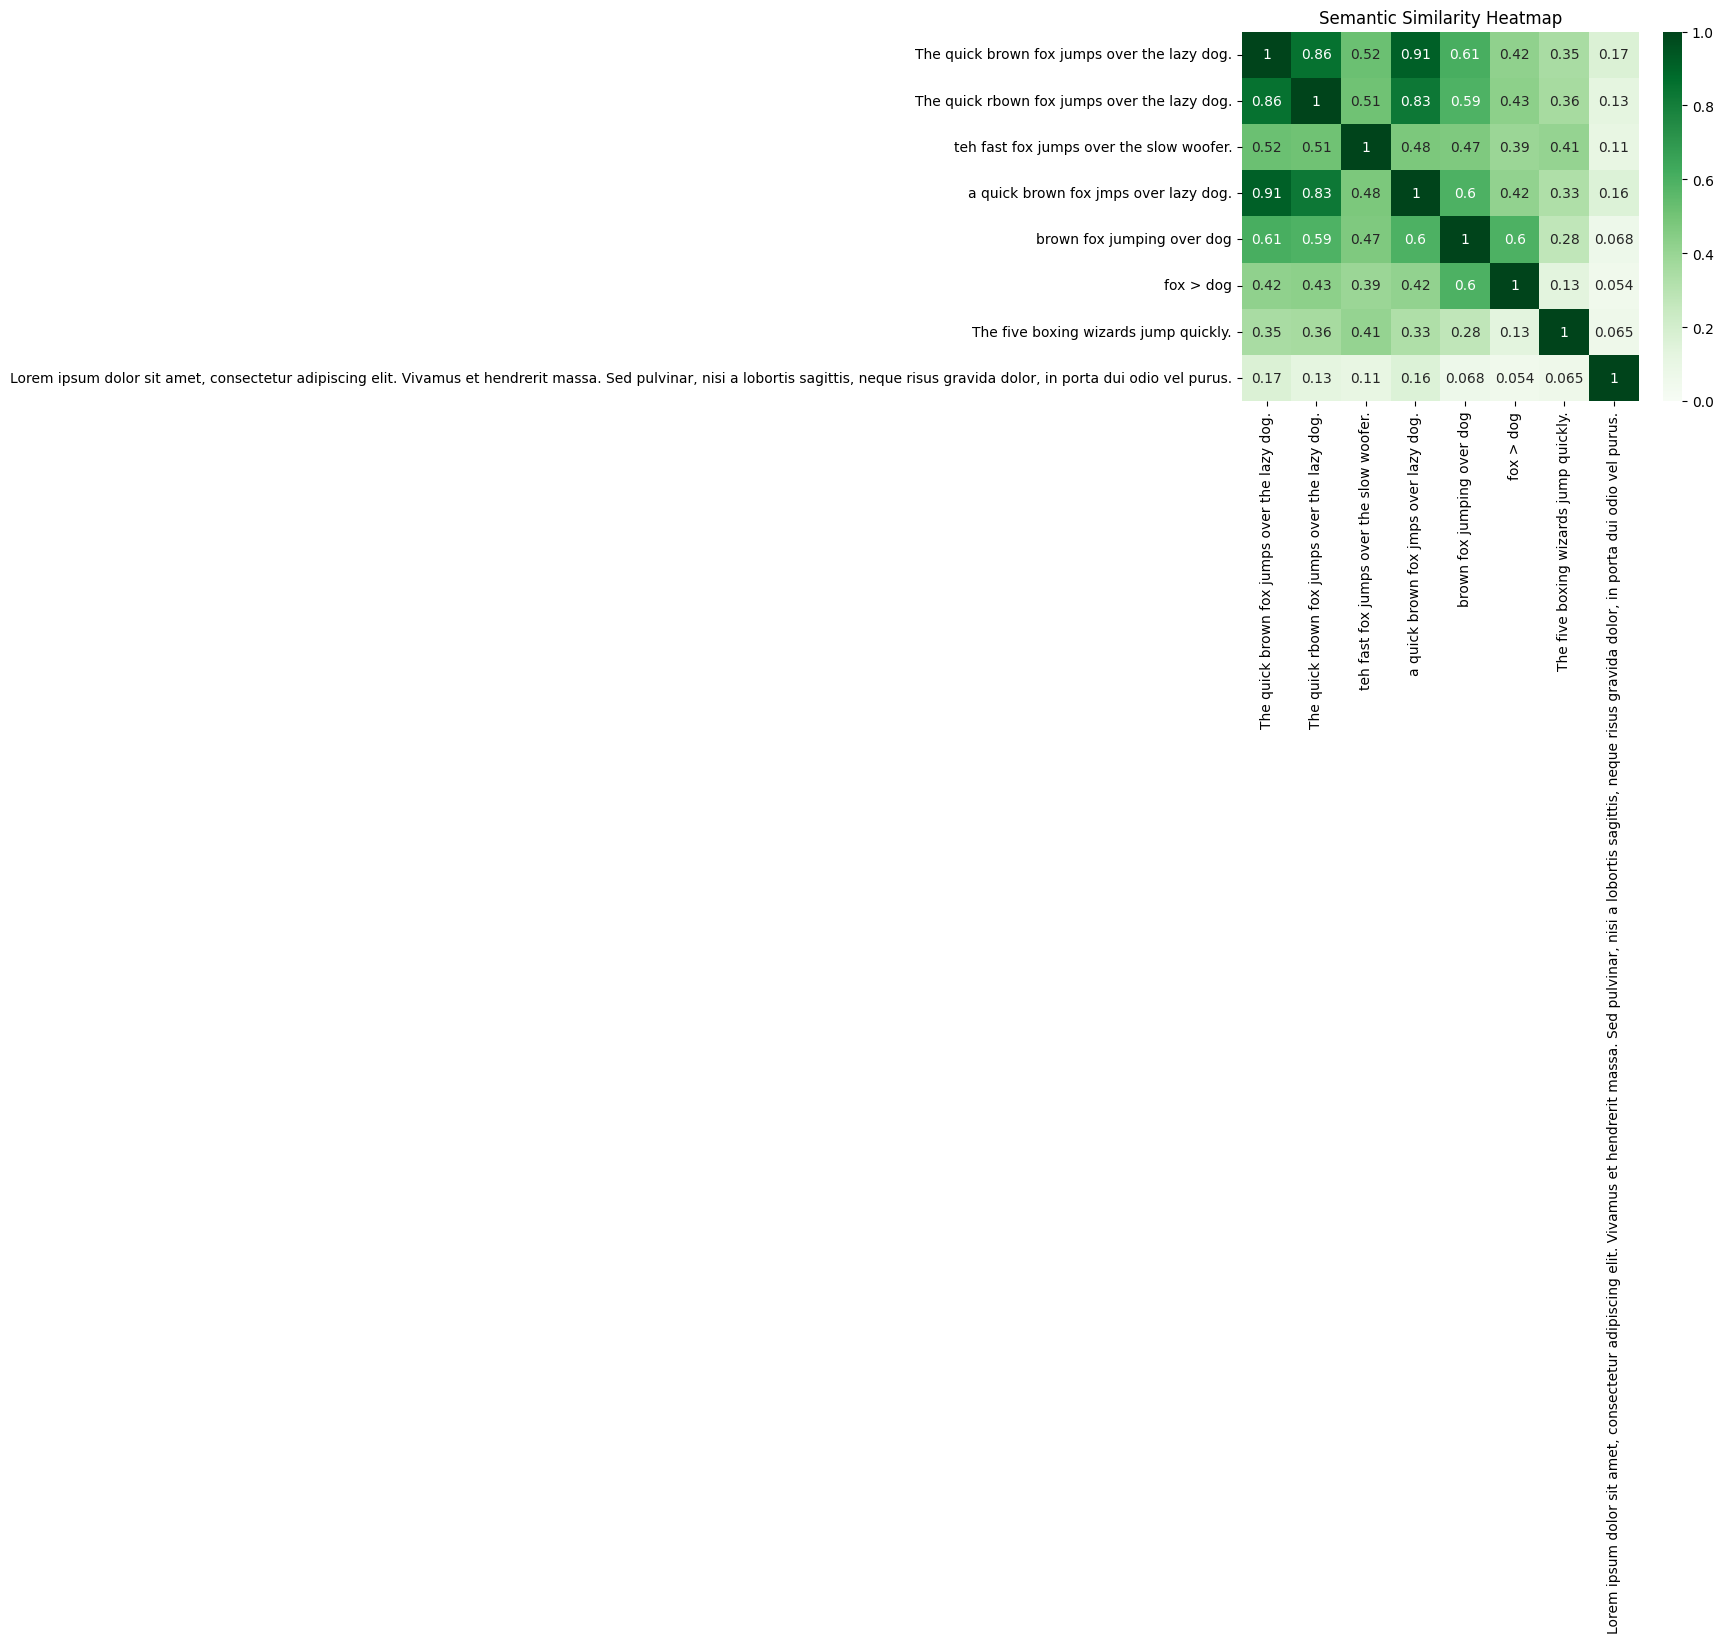

In [22]:
# Draw!
# plt.figure(figsize=(10, 8))
sns.heatmap(sim, annot=True, vmin=0, vmax=1, cmap="Greens")
plt.title("Semantic Similarity Heatmap")
plt.show()

You can see the scores for a particular term directly by looking it up in the dataframe.

In [23]:
print(sim['The quick brown fox jumps over the lazy dog.'].sort_values(ascending=False))

The quick brown fox jumps over the lazy dog.                                                                                                                                            1.000861
a quick brown fox jmps over lazy dog.                                                                                                                                                   0.911227
The quick rbown fox jumps over the lazy dog.                                                                                                                                            0.855384
brown fox jumping over dog                                                                                                                                                              0.608608
teh fast fox jumps over the slow woofer.                                                                                                                                                0.521211
fox > dog                          

## Further reading

* [OpenRouter Embeddings API](https://openrouter.ai/docs/api-reference/embeddings) and [available embedding models](https://openrouter.ai/models?fmt=cards&output_modalities=embeddings)
* [OpenAI embeddings documentation](https://platform.openai.com/docs/guides/embeddings) and [similarity search use cases](https://platform.openai.com/docs/guides/embeddings/use-cases)